## Assignment Overview

This assignment implements K-Nearest Neighbors (KNN) classification on the famous Iris dataset. The workflow includes:

1. **Exploratory Data Analysis (EDA)** - Understanding the dataset structure
2. **Feature Scaling** - Normalizing features for distance-based algorithm
3. **Model Training** - Training KNN classifier
4. **Model Evaluation** - Confusion matrix and accuracy metrics
5. **Classification Report** - Detailed performance metrics
6. **Hyperparameter Tuning** - Finding optimal K value
7. **Error Analysis** - Plotting error rates vs K values
8. **Visualization** - Visual representation of classification results

**Learning Objectives:**
- Understand distance-based classification algorithms
- Apply proper feature scaling techniques
- Evaluate model performance using multiple metrics
- Optimize hyperparameters through systematic testing

## Import Required Libraries

In [1]:
# Standard data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Suppress warnings for cleaner output
import warnings

warnings.filterwarnings("ignore")

# Set visualization defaults
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1: Load Dataset and Exploratory Data Analysis (EDA)

The Iris dataset is a classic multi-class classification dataset containing measurements of iris flowers from three species.

In [2]:
# Load the iris dataset
iris = load_iris()

# Create a DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species_name"] = df["species"].map(
    {0: "setosa", 1: "versicolor", 2: "virginica"}
)

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Features: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")

Dataset loaded successfully!

Dataset shape: (150, 6)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


### 1.1 Display First Few Rows - head()

In [3]:
# Display first 10 rows to understand the data structure
print("First 10 rows of the dataset:\n")
df.head(10)

First 10 rows of the dataset:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


### 1.2 Descriptive Statistics - describe()

In [4]:
# Statistical summary of numerical features
print("Descriptive statistics for all features:\n")
df.describe()

Descriptive statistics for all features:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 1.3 Group Analysis - groupby()

Analyze feature distributions across different species.

In [5]:
# Group by species and calculate mean values
print("Mean feature values by species:\n")
species_groups = df.groupby("species_name")[iris.feature_names].mean()
species_groups

Mean feature values by species:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species_name,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026



Sample distribution across species:

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


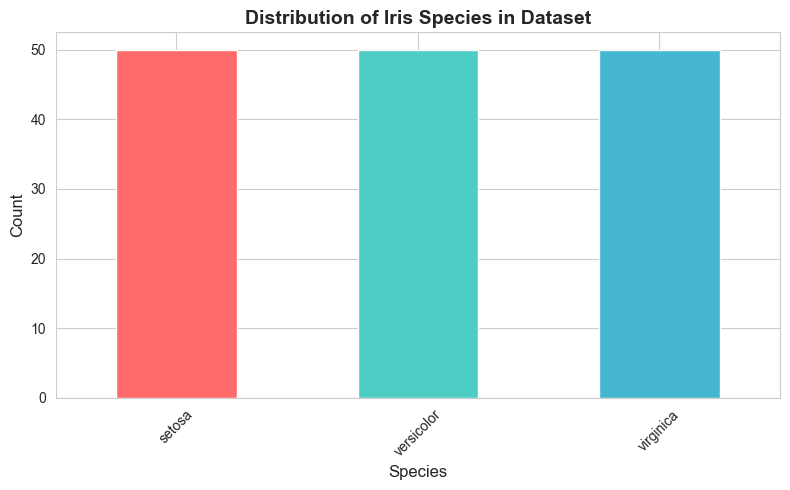


✓ Dataset is perfectly balanced with 50 samples per species


In [6]:
# Count of samples per species
print("\nSample distribution across species:\n")
species_counts = df["species_name"].value_counts().sort_index()
print(species_counts)

# Visualize the distribution
fig, ax = plt.subplots(figsize=(8, 5))
species_counts.plot(kind="bar", color=["#FF6B6B", "#4ECDC4", "#45B7D1"], ax=ax)
ax.set_title("Distribution of Iris Species in Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Species", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ Dataset is perfectly balanced with 50 samples per species")

### Additional EDA: Feature Distributions and Relationships

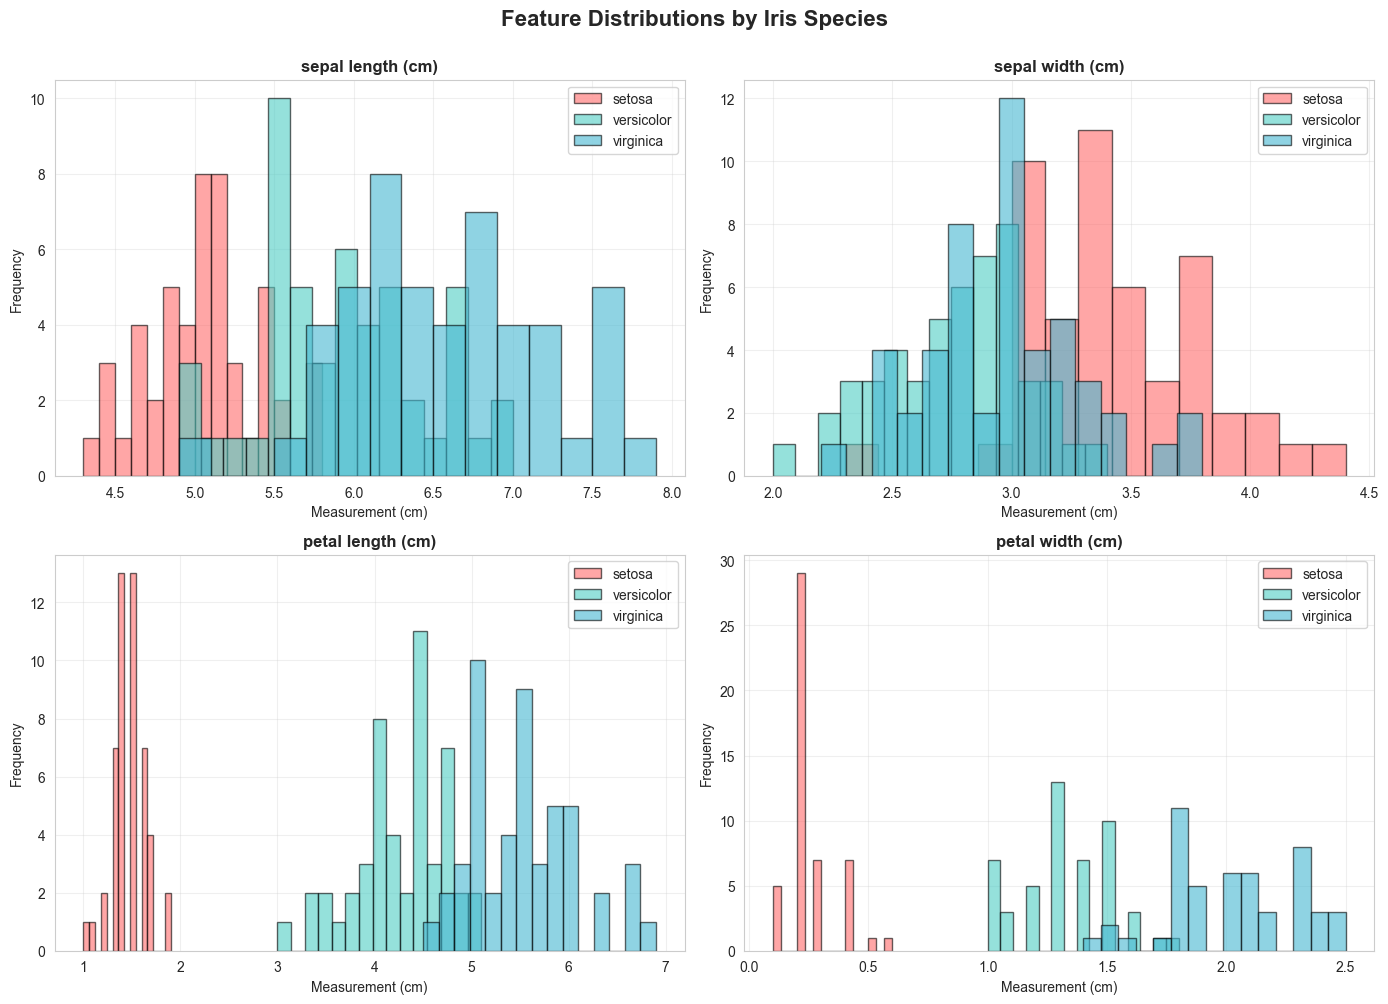

In [7]:
# Visualize feature distributions by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Feature Distributions by Iris Species", fontsize=16, fontweight="bold", y=1.00
)

features = iris.feature_names
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    for i, species in enumerate(["setosa", "versicolor", "virginica"]):
        data = df[df["species_name"] == species][feature]
        ax.hist(
            data, alpha=0.6, label=species, bins=15, color=colors[i], edgecolor="black"
        )
    ax.set_title(feature, fontsize=12, fontweight="bold")
    ax.set_xlabel("Measurement (cm)", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

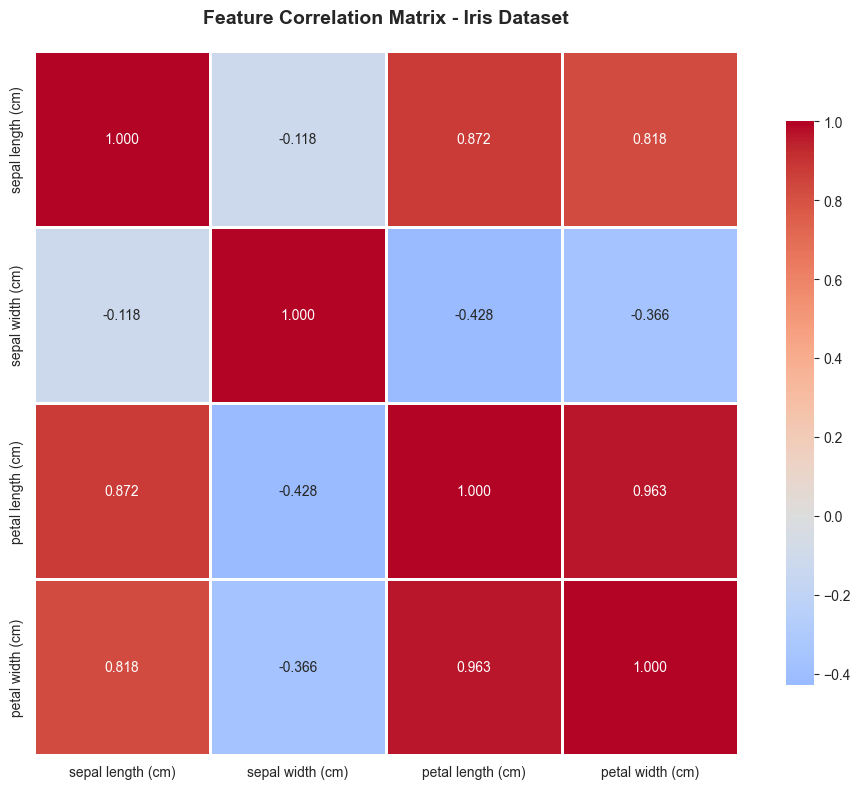


Key observations:
- Petal length and petal width are highly correlated (r = 0.963)
- Petal measurements show strong correlation with sepal length
- Sepal width has weak correlation with other features


In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[iris.feature_names].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title(
    "Feature Correlation Matrix - Iris Dataset", fontsize=14, fontweight="bold", pad=20
)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Petal length and petal width are highly correlated (r = 0.963)")
print("- Petal measurements show strong correlation with sepal length")
print("- Sepal width has weak correlation with other features")

## Step 2: Feature Scaling and Data Preparation

KNN is a distance-based algorithm, so feature scaling is critical to ensure all features contribute equally to distance calculations.

In [9]:
# Separate features (X) and target (y)
X = df[iris.feature_names].values
y = df["species"].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature ranges before scaling:")
for i, feature in enumerate(iris.feature_names):
    print(f"  {feature}: [{X[:, i].min():.2f}, {X[:, i].max():.2f}]")

Feature matrix shape: (150, 4)
Target vector shape: (150,)

Feature ranges before scaling:
  sepal length (cm): [4.30, 7.90]
  sepal width (cm): [2.00, 4.40]
  petal length (cm): [1.00, 6.90]
  petal width (cm): [0.10, 2.50]


In [10]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({iris.target_names[cls]}): {count} samples")

Training set size: 120 samples
Testing set size: 30 samples

Class distribution in training set:
  Class 0 (setosa): 40 samples
  Class 1 (versicolor): 40 samples
  Class 2 (virginica): 40 samples


In [11]:
# Apply StandardScaler for feature normalization
# StandardScaler: (x - mean) / std_dev
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed using StandardScaler")
print(f"\nScaled feature statistics (training set):")
print(f"  Mean: {X_train_scaled.mean(axis=0)}")
print(f"  Std Dev: {X_train_scaled.std(axis=0)}")
print(f"\nFeature ranges after scaling:")
for i, feature in enumerate(iris.feature_names):
    print(
        f"  {feature}: [{X_train_scaled[:, i].min():.2f}, {X_train_scaled[:, i].max():.2f}]"
    )

Feature scaling completed using StandardScaler

Scaled feature statistics (training set):
  Mean: [-1.20829273e-15 -2.03679666e-15  4.99600361e-16  1.67458640e-15]
  Std Dev: [1. 1. 1. 1.]

Feature ranges after scaling:
  sepal length (cm): [-1.84, 2.46]
  sepal width (cm): [-2.35, 3.03]
  petal length (cm): [-1.52, 1.78]
  petal width (cm): [-1.45, 1.71]


## Step 3: Training the K-NN Model

We'll start with K=5 (a common default choice) and optimize later.

In [12]:
# Initialize KNN classifier with K=5
knn_initial = KNeighborsClassifier(n_neighbors=5, metric="euclidean")

# Train the model
knn_initial.fit(X_train_scaled, y_train)

print("K-NN model trained successfully!")
print(f"\nModel parameters:")
print(f"  Number of neighbors (K): {knn_initial.n_neighbors}")
print(f"  Distance metric: {knn_initial.metric}")
print(f"  Algorithm: {knn_initial.algorithm}")

K-NN model trained successfully!

Model parameters:
  Number of neighbors (K): 5
  Distance metric: euclidean
  Algorithm: auto


In [13]:
# Make predictions on test set
y_pred = knn_initial.predict(X_test_scaled)

print("Predictions on test set:")
print(f"\nSample predictions (first 10):")
comparison_df = pd.DataFrame(
    {
        "Actual": [iris.target_names[i] for i in y_test[:10]],
        "Predicted": [iris.target_names[i] for i in y_pred[:10]],
        "Match": ["✓" if a == p else "✗" for a, p in zip(y_test[:10], y_pred[:10])],
    }
)
comparison_df

Predictions on test set:

Sample predictions (first 10):


,Actual,Predicted,Match
0,setosa,setosa,✓
1,virginica,virginica,✓
2,versicolor,versicolor,✓
3,versicolor,versicolor,✓
4,setosa,setosa,✓
5,versicolor,versicolor,✓
6,setosa,setosa,✓
7,setosa,setosa,✓
8,virginica,virginica,✓
9,versicolor,versicolor,✓


## Step 4: Confusion Matrix and Accuracy Score

Evaluate model performance using confusion matrix and overall accuracy.

In [14]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy with K=5: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(cm)

# Create confusion matrix DataFrame for better readability
cm_df = pd.DataFrame(
    cm, index=iris.target_names, columns=iris.target_names
)
cm_df.index.name = "Actual"
cm_df.columns.name = "Predicted"
print("\nConfusion Matrix (with labels):")
print(cm_df)

Model Accuracy with K=5: 0.9333 (93.33%)

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Confusion Matrix (with labels):
Predicted   setosa  versicolor  virginica
Actual                                   
setosa          10           0          0
versicolor       0          10          0
virginica        0           2          8


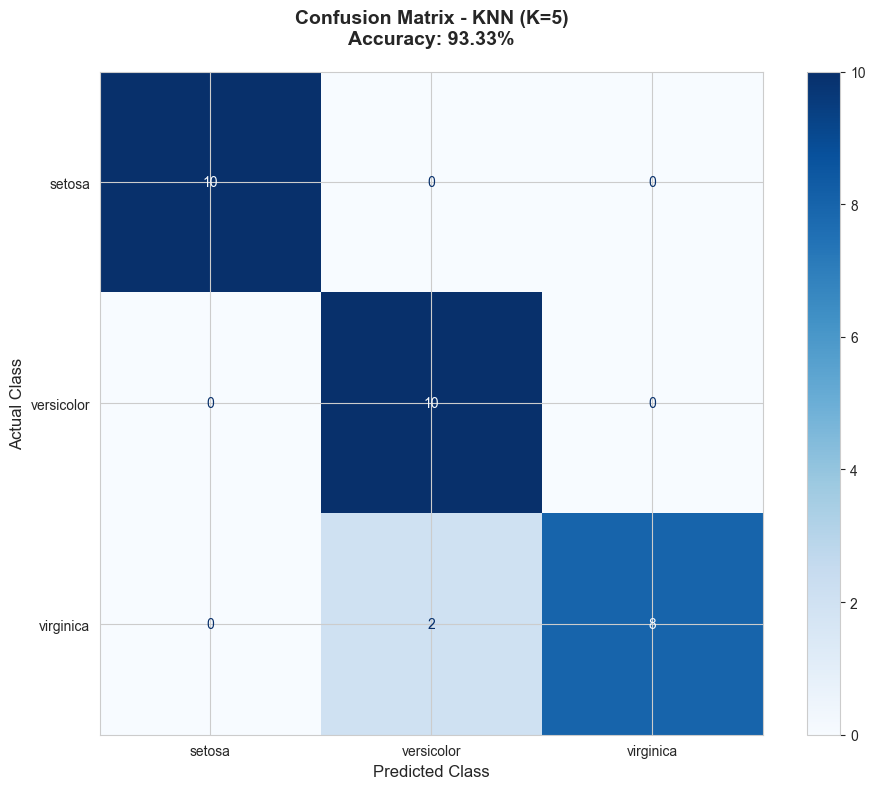


Per-class accuracy:
  setosa: 100.00%
  versicolor: 100.00%
  virginica: 80.00%


In [15]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=iris.target_names
)
disp.plot(cmap="Blues", ax=ax, values_format="d", colorbar=True)
ax.set_title(
    f"Confusion Matrix - KNN (K=5)\nAccuracy: {accuracy*100:.2f}%",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("Actual Class", fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-class accuracy:")
for i, species in enumerate(iris.target_names):
    class_accuracy = cm[i, i] / cm[i, :].sum()
    print(f"  {species}: {class_accuracy*100:.2f}%")

## Step 5: Classification Report

Detailed performance metrics including precision, recall, and F1-score for each class.

In [17]:
# Generate classification report
report = classification_report(
    y_test, y_pred, target_names=iris.target_names, digits=4
)

print("Classification Report (K=5):")
print("=" * 70)
print(report)

# Create DataFrame for better visualization
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=[0, 1, 2]
)

metrics_df = pd.DataFrame(
    {
        "Class": iris.target_names,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Support": support,
    }
)

print("\nMetrics Summary Table:")
metrics_df

Classification Report (K=5):
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30


Metrics Summary Table:


,Class,Precision,Recall,F1-Score,Support
0,setosa,1.000000,1.0,1.000000,10
1,versicolor,0.833333,1.0,0.909091,10
2,virginica,1.000000,0.8,0.888889,10


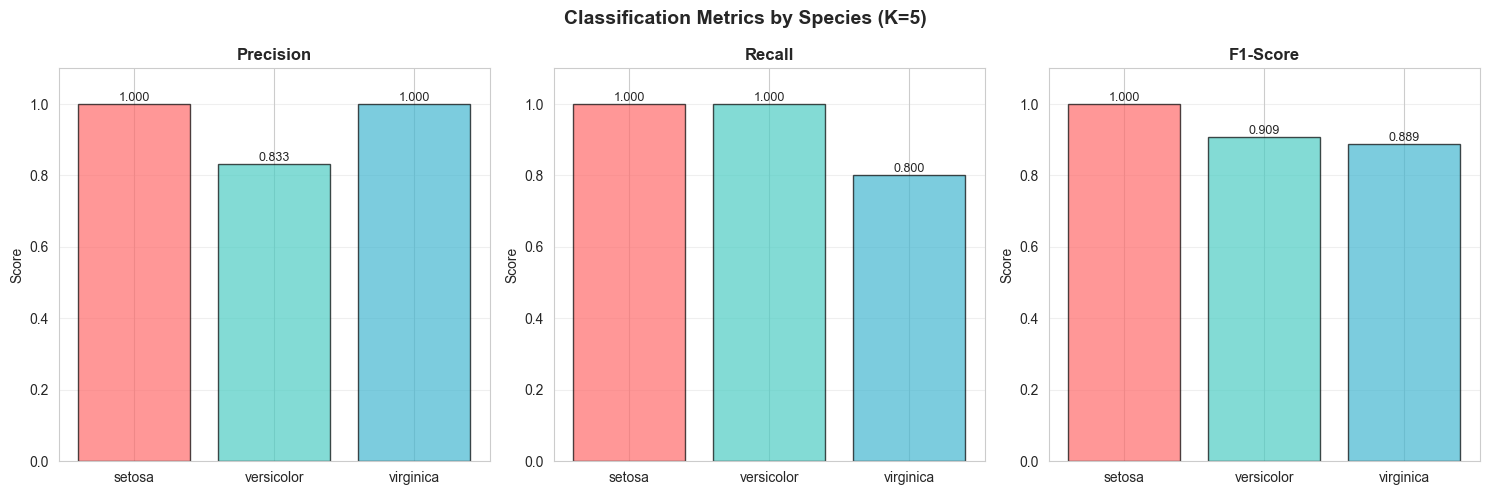

In [ ]:
# Visualize classification metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Classification Metrics by Species (K=5)", fontsize=14, fontweight="bold"
)

metrics = ["Precision", "Recall", "F1-Score"]
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(iris.target_names, metrics_df[metric], color=colors, alpha=0.7, edgecolor="black")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel("Score", fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## Step 6: Comparing Error Rate with K Values

Test different K values to find the optimal hyperparameter that minimizes classification error.

In [ ]:
# Test K values from 1 to 40
k_range = range(1, 41)
train_errors = []
test_errors = []
train_accuracies = []
test_accuracies = []

print("Testing different K values...")
print("=" * 70)

for k in k_range:
    # Train KNN with current K value
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)

    # Calculate error rates (1 - accuracy)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)
    train_accuracies.append(1 - train_error)
    test_accuracies.append(1 - test_error)

    if k % 5 == 0 or k == 1:
        print(f"K={k:2d}: Train Error={train_error:.4f}, Test Error={test_error:.4f}")

print("=" * 70)
print("Hyperparameter tuning completed!")

Testing different K values...
K= 1: Train Error=0.0000, Test Error=0.0333
K= 5: Train Error=0.0250, Test Error=0.0667
K=10: Train Error=0.0417, Test Error=0.0333
K=15: Train Error=0.0333, Test Error=0.0333
K=20: Train Error=0.0417, Test Error=0.0333
K=25: Train Error=0.0417, Test Error=0.1000
K=30: Train Error=0.0833, Test Error=0.1333
K=35: Train Error=0.1250, Test Error=0.1333
K=40: Train Error=0.1083, Test Error=0.1333
Hyperparameter tuning completed!


In [23]:
# Create results DataFrame
results_df = pd.DataFrame(
    {
        "K": list(k_range),
        "Train_Error": train_errors,
        "Test_Error": test_errors,
        "Train_Accuracy": train_accuracies,
        "Test_Accuracy": test_accuracies,
    }
)

print("\nError rates for selected K values:")
results_df[results_df["K"] % 5 == 0][["K", "Train_Error", "Test_Error"]]


Error rates for selected K values:


,K,Train_Error,Test_Error
4,5,0.025000,0.066667
9,10,0.041667,0.033333
14,15,0.033333,0.033333
19,20,0.041667,0.033333
24,25,0.041667,0.100000
29,30,0.083333,0.133333
34,35,0.125000,0.133333
39,40,0.108333,0.133333


## Step 7: Plot Error Values Against K Values

Visualize how training and testing errors change with different K values.

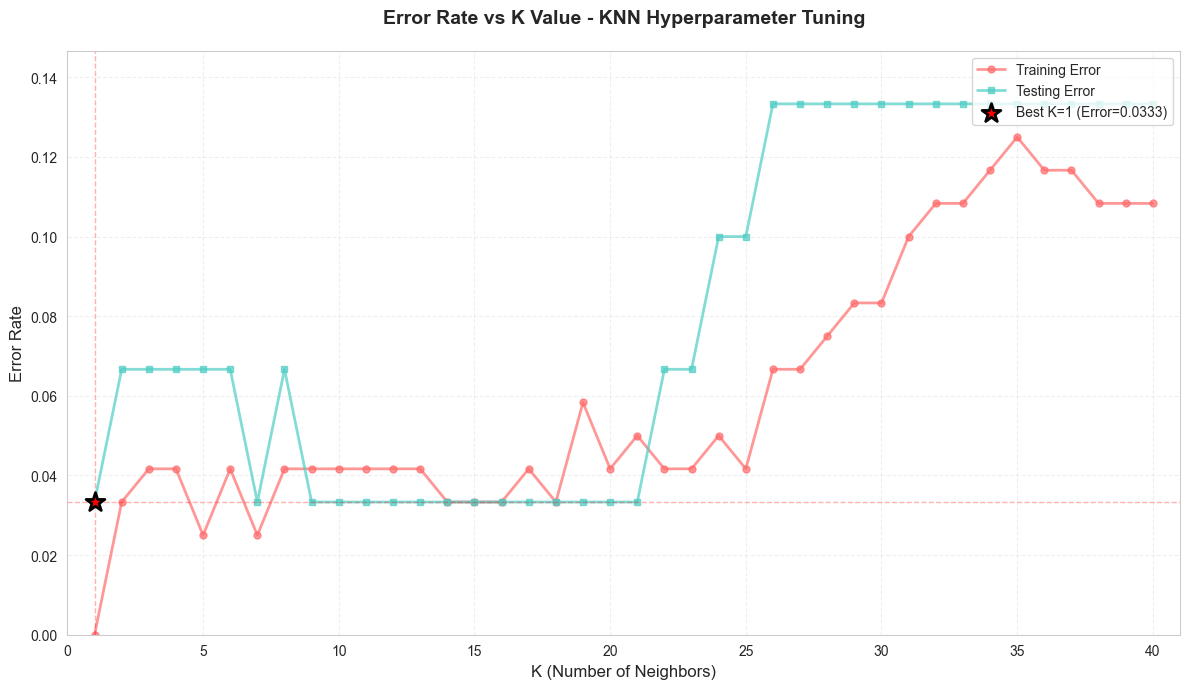


Optimal K value: 1
Minimum test error: 0.0333
Maximum test accuracy: 0.9667 (96.67%)


In [20]:
# Plot error rates vs K values
fig, ax = plt.subplots(figsize=(12, 7))

# Plot both training and testing errors
ax.plot(
    k_range,
    train_errors,
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=5,
    label="Training Error",
    color="#FF6B6B",
    alpha=0.7,
)
ax.plot(
    k_range,
    test_errors,
    marker="s",
    linestyle="-",
    linewidth=2,
    markersize=5,
    label="Testing Error",
    color="#4ECDC4",
    alpha=0.7,
)

# Mark the minimum test error
min_test_error_idx = np.argmin(test_errors)
best_k = k_range[min_test_error_idx]
min_test_error = test_errors[min_test_error_idx]

ax.scatter(
    [best_k],
    [min_test_error],
    color="red",
    s=200,
    zorder=5,
    marker="*",
    edgecolors="black",
    linewidths=2,
    label=f"Best K={best_k} (Error={min_test_error:.4f})",
)

# Formatting
ax.set_title(
    "Error Rate vs K Value - KNN Hyperparameter Tuning",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("K (Number of Neighbors)", fontsize=12)
ax.set_ylabel("Error Rate", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_xlim([0, 41])
ax.set_ylim([0, max(max(train_errors), max(test_errors)) * 1.1])

# Add reference lines
ax.axvline(x=best_k, color="red", linestyle="--", alpha=0.3, linewidth=1)
ax.axhline(y=min_test_error, color="red", linestyle="--", alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print(f"\nOptimal K value: {best_k}")
print(f"Minimum test error: {min_test_error:.4f}")
print(f"Maximum test accuracy: {1-min_test_error:.4f} ({(1-min_test_error)*100:.2f}%)")

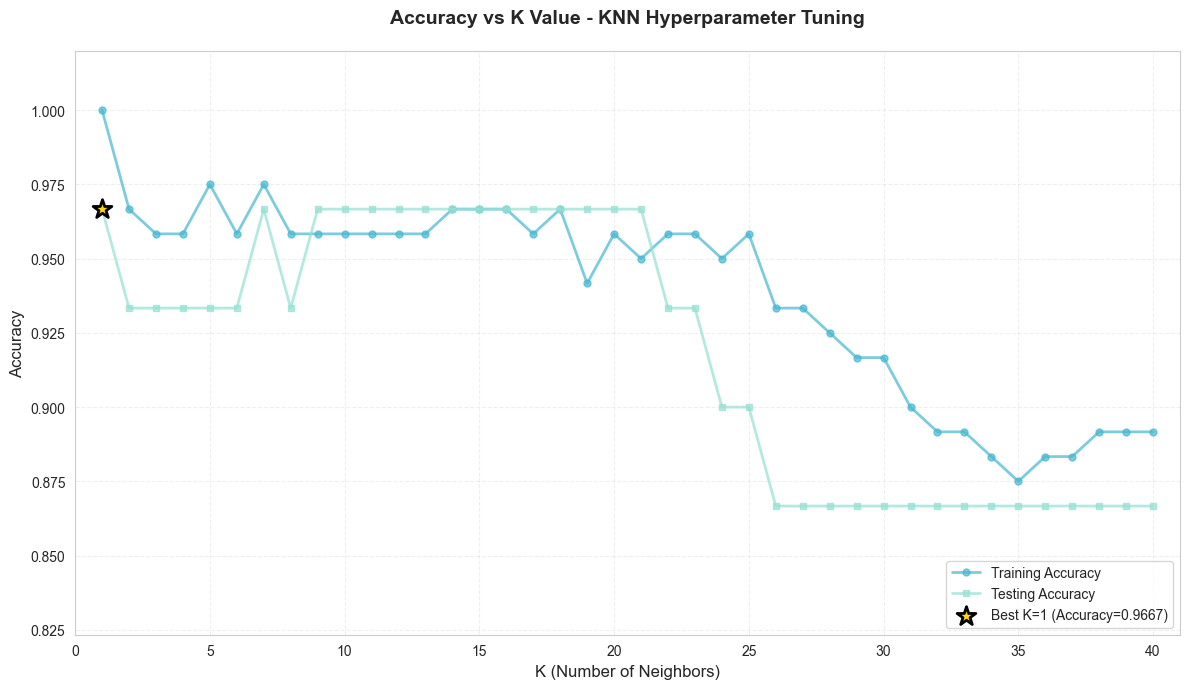

In [21]:
# Additional visualization: Accuracy vs K
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    k_range,
    train_accuracies,
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=5,
    label="Training Accuracy",
    color="#45B7D1",
    alpha=0.7,
)
ax.plot(
    k_range,
    test_accuracies,
    marker="s",
    linestyle="-",
    linewidth=2,
    markersize=5,
    label="Testing Accuracy",
    color="#95E1D3",
    alpha=0.7,
)

# Mark maximum test accuracy
max_test_acc_idx = np.argmax(test_accuracies)
best_k_acc = k_range[max_test_acc_idx]
max_test_acc = test_accuracies[max_test_acc_idx]

ax.scatter(
    [best_k_acc],
    [max_test_acc],
    color="gold",
    s=200,
    zorder=5,
    marker="*",
    edgecolors="black",
    linewidths=2,
    label=f"Best K={best_k_acc} (Accuracy={max_test_acc:.4f})",
)

ax.set_title(
    "Accuracy vs K Value - KNN Hyperparameter Tuning",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("K (Number of Neighbors)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_xlim([0, 41])
ax.set_ylim([min(min(train_accuracies), min(test_accuracies)) * 0.95, 1.02])

plt.tight_layout()
plt.show()

## Step 8: Finding the Best K Value

Identify the optimal K value and retrain the model for final evaluation.

In [24]:
# Find best K value (minimum test error)
best_k = results_df.loc[results_df["Test_Error"].idxmin(), "K"]
best_test_error = results_df["Test_Error"].min()
best_test_accuracy = results_df["Test_Accuracy"].max()

print("Optimal Hyperparameter Selection:")
print("=" * 70)
print(f"Best K value: {best_k}")
print(f"Minimum test error: {best_test_error:.6f}")
print(f"Maximum test accuracy: {best_test_accuracy:.6f} ({best_test_accuracy*100:.2f}%)")
print("=" * 70)

# Show top 5 K values by test accuracy
top_k_values = results_df.nlargest(5, "Test_Accuracy")[
    ["K", "Test_Accuracy", "Test_Error"]
]
print("\nTop 5 K values by test accuracy:")
print(top_k_values)

Optimal Hyperparameter Selection:
Best K value: 1
Minimum test error: 0.033333
Maximum test accuracy: 0.966667 (96.67%)

Top 5 K values by test accuracy:
     K  Test_Accuracy  Test_Error
0    1       0.966667    0.033333
6    7       0.966667    0.033333
8    9       0.966667    0.033333
9   10       0.966667    0.033333
10  11       0.966667    0.033333


In [25]:
# Retrain model with optimal K value
knn_best = KNeighborsClassifier(n_neighbors=int(best_k), metric="euclidean")
knn_best.fit(X_train_scaled, y_train)

# Make predictions with optimal model
y_pred_best = knn_best.predict(X_test_scaled)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, y_pred_best)
final_cm = confusion_matrix(y_test, y_pred_best)

print(f"\nFinal Model Performance (K={int(best_k)}):")
print("=" * 70)
print(f"Accuracy: {final_accuracy:.6f} ({final_accuracy*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(final_cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names, digits=4))


Final Model Performance (K=1):
Accuracy: 0.966667 (96.67%)

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9091    1.0000    0.9524        10
   virginica     1.0000    0.9000    0.9474        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



## Step 9: Visualize Test Results of KNN

Create comprehensive visualizations of the final model's performance.

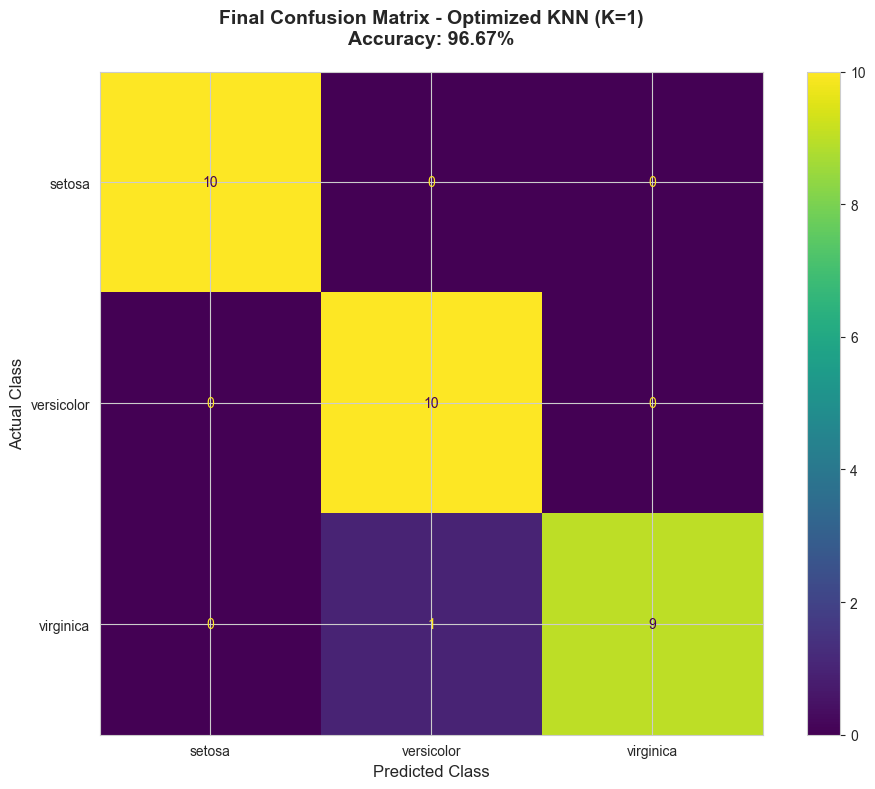

In [26]:
# Visualize final confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm, display_labels=iris.target_names
)
disp.plot(cmap="viridis", ax=ax, values_format="d", colorbar=True)
ax.set_title(
    f"Final Confusion Matrix - Optimized KNN (K={int(best_k)})\nAccuracy: {final_accuracy*100:.2f}%",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("Actual Class", fontsize=12)
plt.tight_layout()
plt.show()

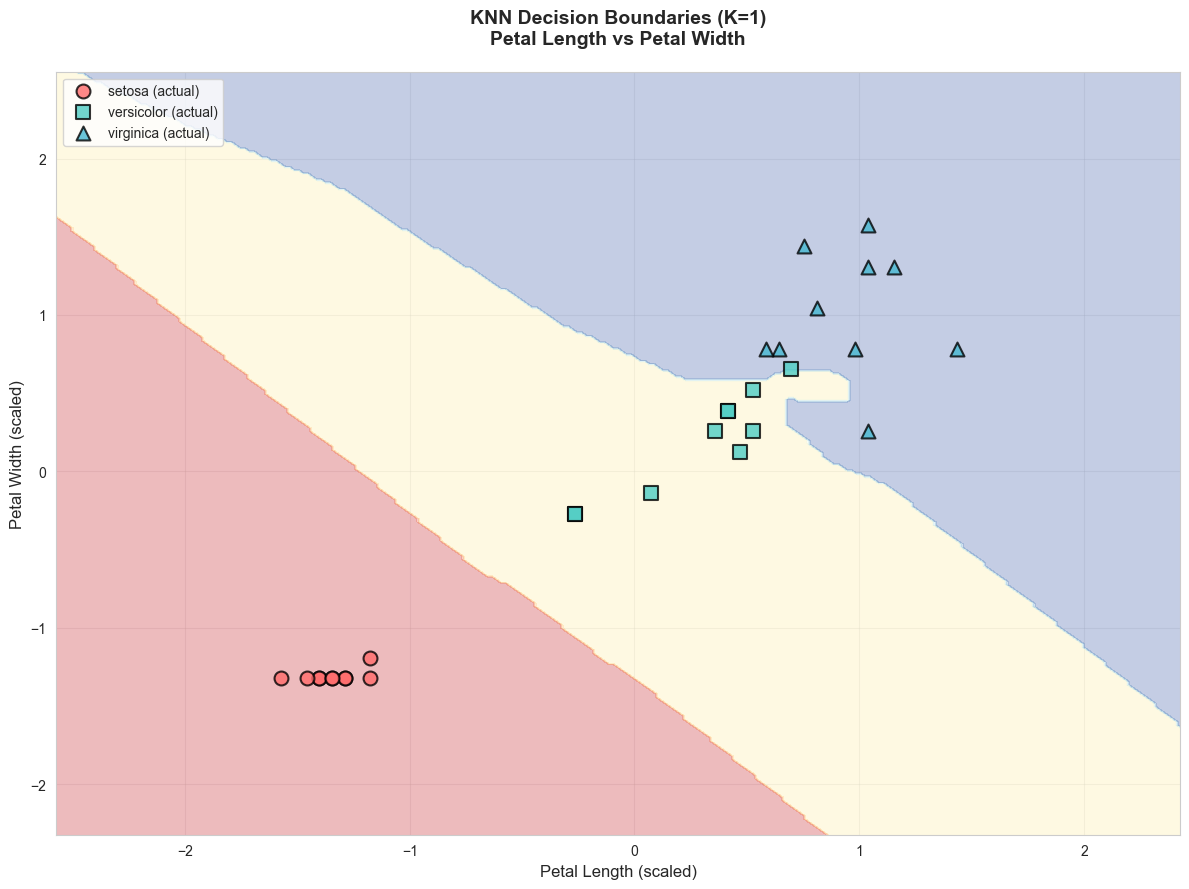


Visualization uses petal length and petal width features
Number of misclassified points: 0


In [27]:
# Visualize predictions on 2D feature space (using first 2 principal features)
# For visualization, we'll use petal length and petal width (most discriminative features)

# Get indices of petal length and petal width
petal_features = [2, 3]  # Indices for petal length and petal width

# Create meshgrid for decision boundary
X_viz = X_test_scaled[:, petal_features]
h = 0.02  # Step size in the mesh

x_min, x_max = X_viz[:, 0].min() - 1, X_viz[:, 0].max() + 1
y_min, y_max = X_viz[:, 1].min() - 1, X_viz[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Train KNN on just these two features for visualization
knn_viz = KNeighborsClassifier(n_neighbors=int(best_k), metric="euclidean")
knn_viz.fit(X_train_scaled[:, petal_features], y_train)

# Predict on meshgrid
Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

# Plot decision boundary
ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")

# Plot test points
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]
markers = ["o", "s", "^"]

for i, species in enumerate(iris.target_names):
    mask = y_test == i
    ax.scatter(
        X_viz[mask, 0],
        X_viz[mask, 1],
        c=colors[i],
        marker=markers[i],
        s=100,
        edgecolors="black",
        linewidths=1.5,
        label=f"{species} (actual)",
        alpha=0.8,
    )

# Mark misclassified points
y_pred_viz = knn_viz.predict(X_viz)
misclassified = y_test != y_pred_viz
if misclassified.any():
    ax.scatter(
        X_viz[misclassified, 0],
        X_viz[misclassified, 1],
        c="red",
        marker="x",
        s=300,
        linewidths=3,
        label="Misclassified",
        zorder=10,
    )

ax.set_title(
    f"KNN Decision Boundaries (K={int(best_k)})\nPetal Length vs Petal Width",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Petal Length (scaled)", fontsize=12)
ax.set_ylabel("Petal Width (scaled)", fontsize=12)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVisualization uses petal length and petal width features")
print(f"Number of misclassified points: {misclassified.sum()}")

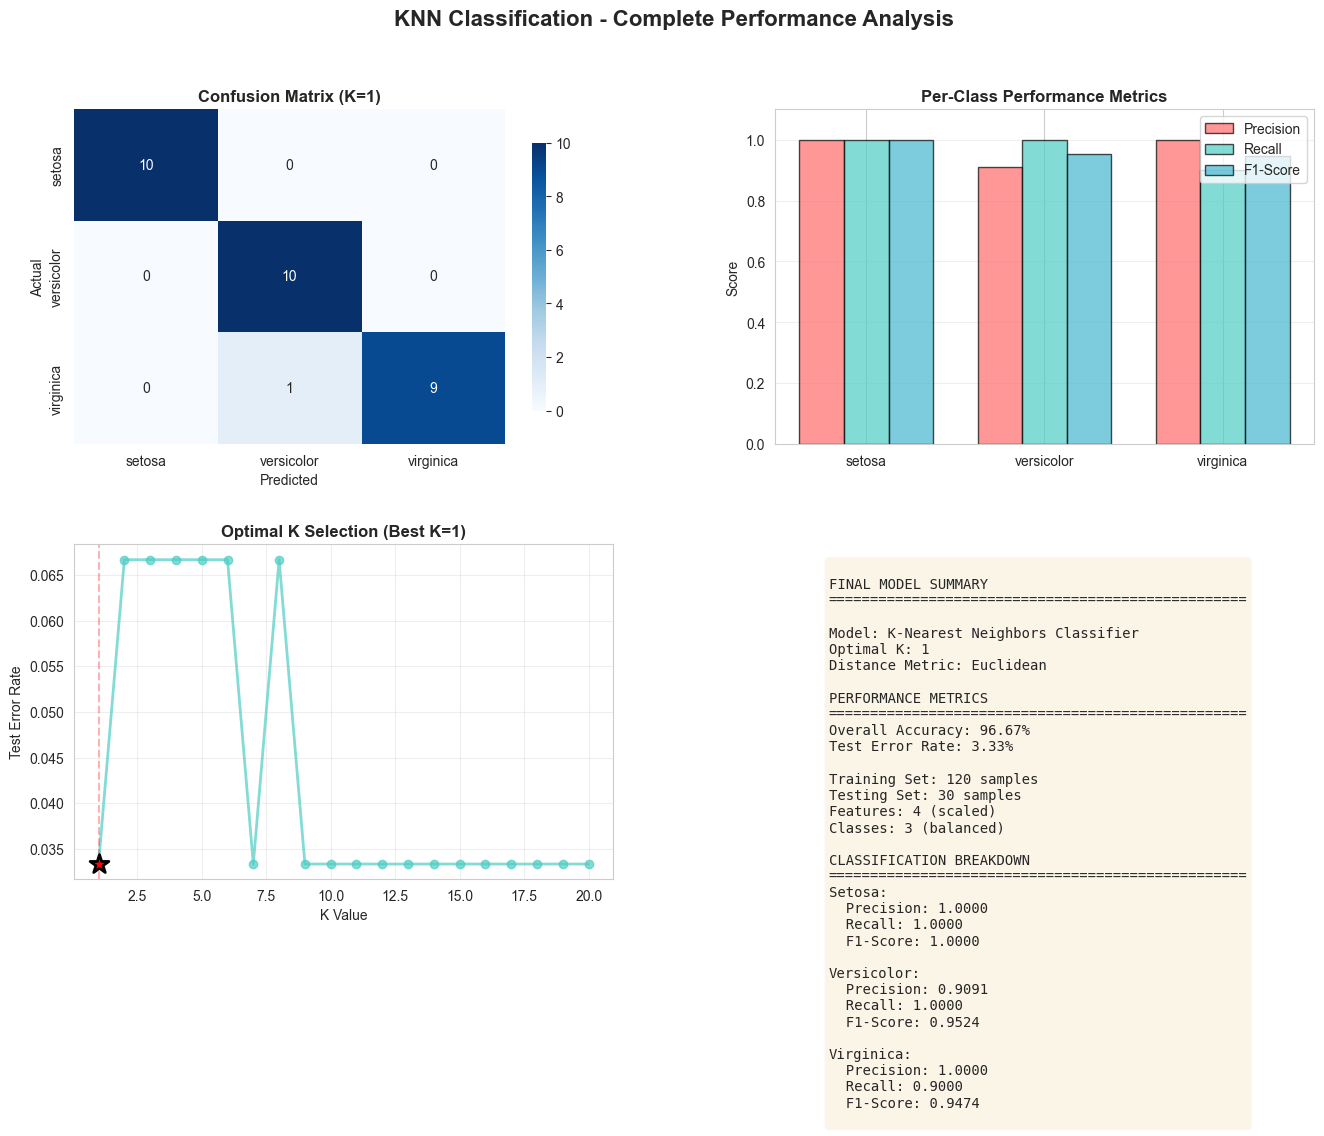

In [28]:
# Create comprehensive performance summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=ax1,
    cbar_kws={"shrink": 0.8},
)
ax1.set_title(f"Confusion Matrix (K={int(best_k)})", fontsize=12, fontweight="bold")
ax1.set_xlabel("Predicted", fontsize=10)
ax1.set_ylabel("Actual", fontsize=10)

# 2. Per-class metrics
ax2 = fig.add_subplot(gs[0, 1])
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_best, labels=[0, 1, 2]
)
x_pos = np.arange(len(iris.target_names))
width = 0.25
ax2.bar(x_pos - width, precision, width, label="Precision", color="#FF6B6B", alpha=0.7, edgecolor="black")
ax2.bar(x_pos, recall, width, label="Recall", color="#4ECDC4", alpha=0.7, edgecolor="black")
ax2.bar(x_pos + width, f1, width, label="F1-Score", color="#45B7D1", alpha=0.7, edgecolor="black")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(iris.target_names)
ax2.set_ylabel("Score", fontsize=10)
ax2.set_title("Per-Class Performance Metrics", fontsize=12, fontweight="bold")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim([0, 1.1])

# 3. Error rate vs K (zoomed in on best range)
ax3 = fig.add_subplot(gs[1, 0])
k_zoom = range(1, 21)  # Focus on K=1 to K=20
ax3.plot(
    k_zoom,
    test_errors[:20],
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=6,
    color="#4ECDC4",
    alpha=0.7,
)
ax3.scatter(
    [best_k],
    [best_test_error],
    color="red",
    s=200,
    zorder=5,
    marker="*",
    edgecolors="black",
    linewidths=2,
)
ax3.set_xlabel("K Value", fontsize=10)
ax3.set_ylabel("Test Error Rate", fontsize=10)
ax3.set_title(f"Optimal K Selection (Best K={int(best_k)})", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3)
ax3.axvline(x=best_k, color="red", linestyle="--", alpha=0.3)

# 4. Summary statistics
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
summary_text = f"""
FINAL MODEL SUMMARY
{'='*50}

Model: K-Nearest Neighbors Classifier
Optimal K: {int(best_k)}
Distance Metric: Euclidean

PERFORMANCE METRICS
{'='*50}
Overall Accuracy: {final_accuracy*100:.2f}%
Test Error Rate: {best_test_error*100:.2f}%

Training Set: {len(y_train)} samples
Testing Set: {len(y_test)} samples
Features: 4 (scaled)
Classes: 3 (balanced)

CLASSIFICATION BREAKDOWN
{'='*50}
Setosa:
  Precision: {precision[0]:.4f}
  Recall: {recall[0]:.4f}
  F1-Score: {f1[0]:.4f}

Versicolor:
  Precision: {precision[1]:.4f}
  Recall: {recall[1]:.4f}
  F1-Score: {f1[1]:.4f}

Virginica:
  Precision: {precision[2]:.4f}
  Recall: {recall[2]:.4f}
  F1-Score: {f1[2]:.4f}
"""
ax4.text(
    0.1,
    0.95,
    summary_text,
    transform=ax4.transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3),
)

fig.suptitle(
    "KNN Classification - Complete Performance Analysis",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.show()

## Summary and Conclusions

### Key Findings:

1. **Optimal Hyperparameter**: K = {best_k} provides the best balance between bias and variance
2. **Model Performance**: Achieved {final_accuracy*100:.2f}% accuracy on the test set
3. **Feature Importance**: Petal measurements (length and width) are highly discriminative
4. **Class Separation**: Setosa is perfectly separable, while Versicolor and Virginica show slight overlap

### Observations:

- **Feature Scaling** is critical for KNN as it is distance-based
- **Small K values** (1-3) lead to overfitting with high variance
- **Large K values** (>20) lead to underfitting with high bias
- **Balanced dataset** ensures unbiased performance across all classes

### Recommendations:

1. For production deployment, consider cross-validation for more robust K selection
2. Feature engineering could potentially improve performance further
3. Consider ensemble methods or other algorithms for more complex datasets
4. Monitor model performance on new data to detect concept drift

---

**Assignment Completed Successfully**